In [ ]:
!pip install Pillow matplotlib

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive
import os

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
THU_MUC_ANH = "/content/drive/MyDrive/Lab_CropPaste/"

Các ảnh có sẵn:
1. bai3_flip_horizontal.png
2. bai3_flip_vertical.png

Thông tin ảnh: bai3_flip_horizontal.png
Kích thước: 400 x 267 pixels
Chế độ màu: RGBA
Tỷ lệ khung hình: 1.50


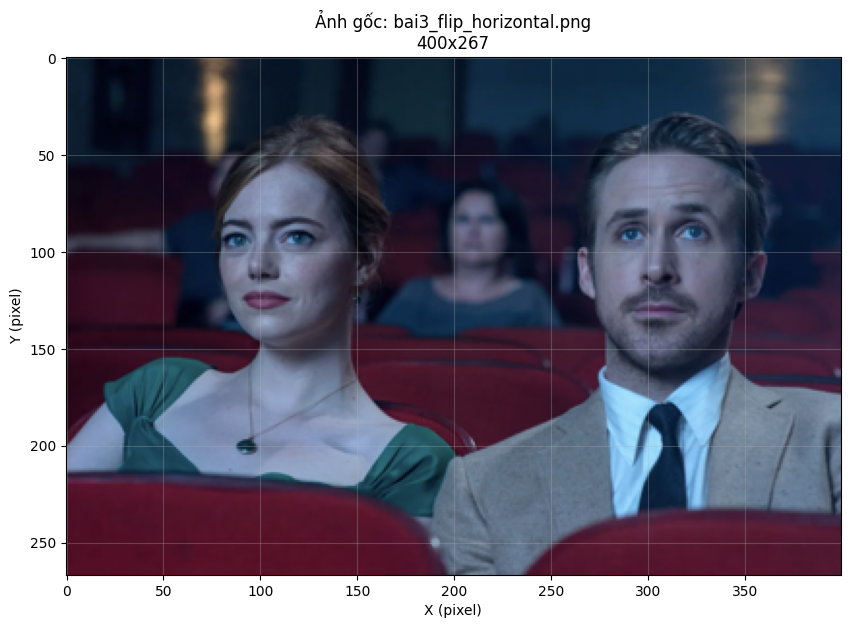

In [8]:
def setup_anh():
  global img_goc, danh_sach_anh, width, height
  # Lấy danh sách ảnh
  files = os.listdir(THU_MUC_ANH)
  danh_sach_anh = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
  print("Các ảnh có sẵn:")
  for i, file in enumerate(danh_sach_anh, 1):
   print(f"{i}. {file}")
  # Mở ảnh đầu tiên
  chon_anh = 0  # Thay đổi để chọn ảnh khác
  duong_dan = os.path.join(THU_MUC_ANH, danh_sach_anh[chon_anh])
  img_goc = Image.open(duong_dan)
  width, height = img_goc.size
  # Hiển thị thông tin ảnh
  print(f"\nThông tin ảnh: {danh_sach_anh[chon_anh]}")
  print(f"Kích thước: {width} x {height} pixels")
  print(f"Chế độ màu: {img_goc.mode}")
  print(f"Tỷ lệ khung hình: {width/height:.2f}")
  # Hiển thị ảnh với lưới tọa độ
  fig, ax = plt.subplots(1, 1, figsize=(10, 8))
  ax.imshow(img_goc)
  ax.set_title(f"Ảnh gốc: {danh_sach_anh[chon_anh]}\n{width}x{height}")
  # Thêm lưới tọa độ để dễ hiểu vị trí cắt
  ax.grid(True, alpha=0.3)
  ax.set_xlabel('X (pixel)')
  ax.set_ylabel('Y (pixel)')
  plt.show()
  return img_goc
img_goc = setup_anh()

=== CẮTEỂN ẢNH CƠ BẢN ===


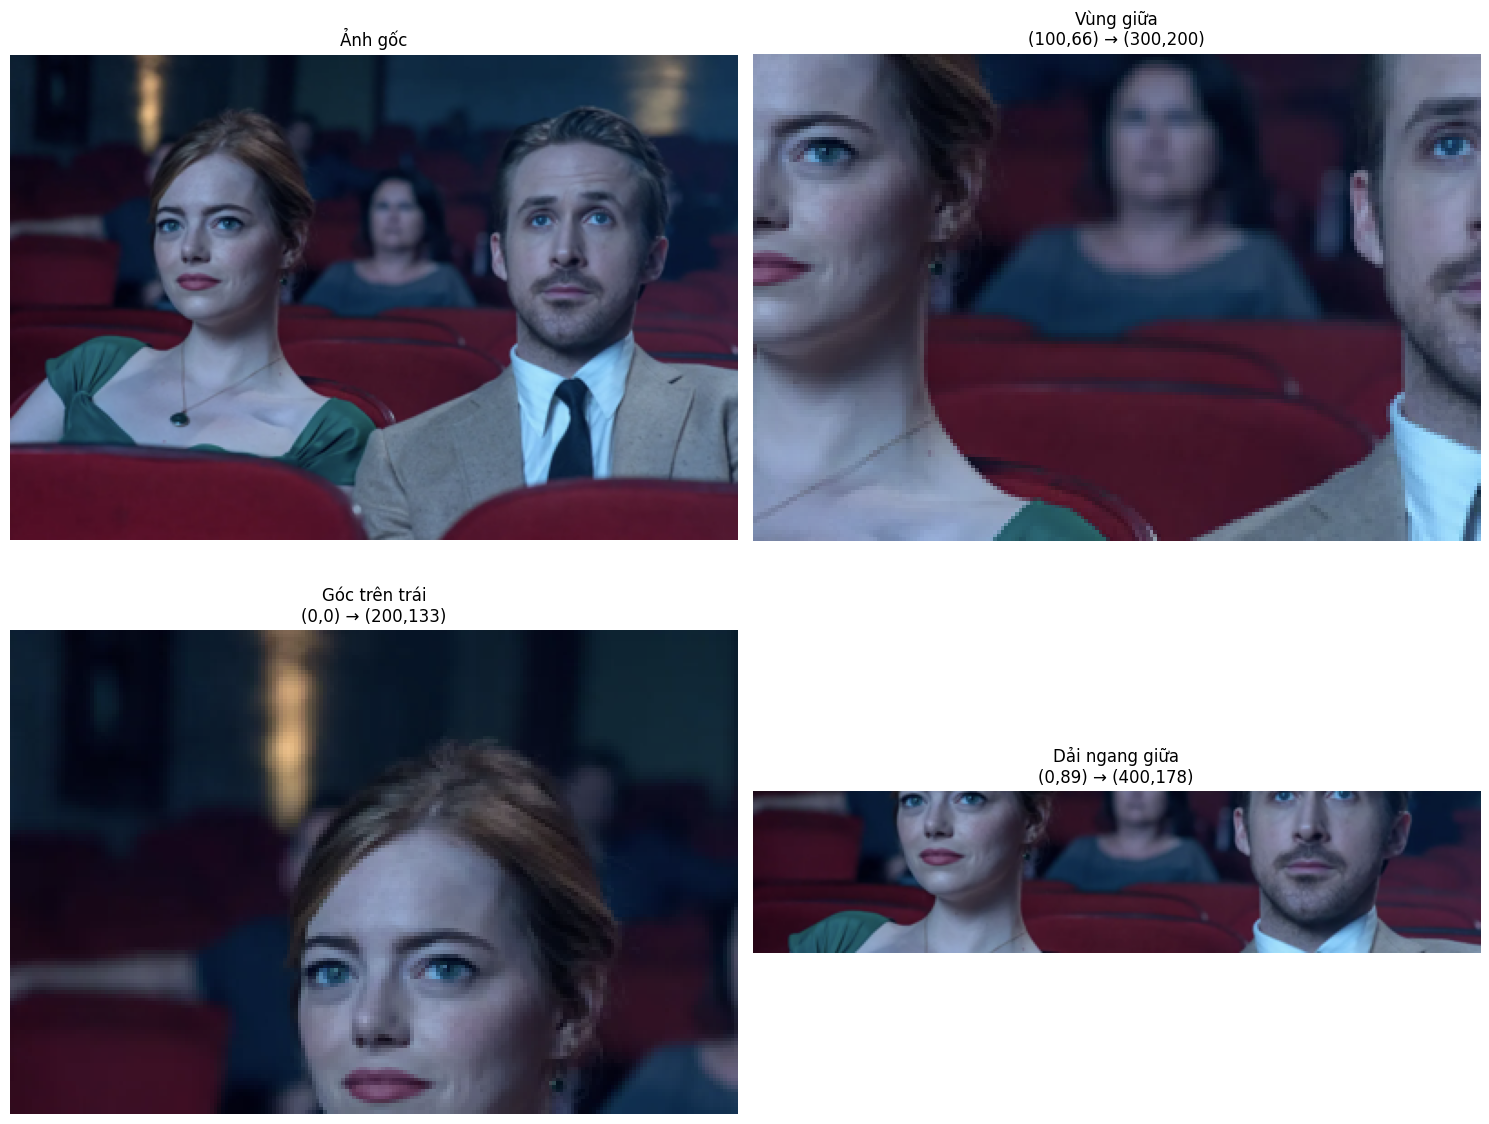

Đã cắt ảnh theo các vùng khác nhau
Lưu ý: Tọa độ (0,0) ở góc trên trái


In [9]:
def cat_anh_co_ban():
  print("=== CẮTEỂN ẢNH CƠ BẢN ===")
  # Cắt vùng giữa ảnh (1/4 từ mỗi cạnh)
  left = width // 4
  top = height // 4
  right = 3 * width // 4
  bottom = 3 * height // 4
  cropped_center = img_goc.crop((left, top, right, bottom))
  # Cắt góc trên trái
  cropped_top_left = img_goc.crop((0, 0, width//2, height//2))
  # Cắt một dải ngang ở giữa
  cropped_horizontal = img_goc.crop((0, height//3, width, 2*height//3))
  # Hiển thị kết quả
  fig, axes = plt.subplots(2, 2, figsize=(15, 12))
  # Ảnh gốc
  axes[0, 0].imshow(img_goc)
  axes[0, 0].set_title('Ảnh gốc')
  axes[0, 0].axis('off')
  # Vùng giữa
  axes[0, 1].imshow(cropped_center)
  axes[0, 1].set_title(f'Vùng giữa\n({left},{top}) → ({right},{bottom})')
  axes[0, 1].axis('off')
  # Góc trên trái
  axes[1, 0].imshow(cropped_top_left)
  axes[1, 0].set_title(f'Góc trên trái\n(0,0) → ({width//2},{height//2})')
  axes[1, 0].axis('off')
  # Dải ngang
  axes[1, 1].imshow(cropped_horizontal)
  axes[1, 1].set_title(f'Dải ngang giữa\n(0,{height//3}) → ({width},{2*height//3})')
  axes[1, 1].axis('off')
  plt.tight_layout()
  plt.show()
  print("Đã cắt ảnh theo các vùng khác nhau")
  print("Lưu ý: Tọa độ (0,0) ở góc trên trái")
  return cropped_center, cropped_top_left, cropped_horizontal
cropped_center, cropped_top_left, cropped_horizontal = cat_anh_co_ban()

=== CẮT ẢNH THÀNH NHIỀU PHẦN ===


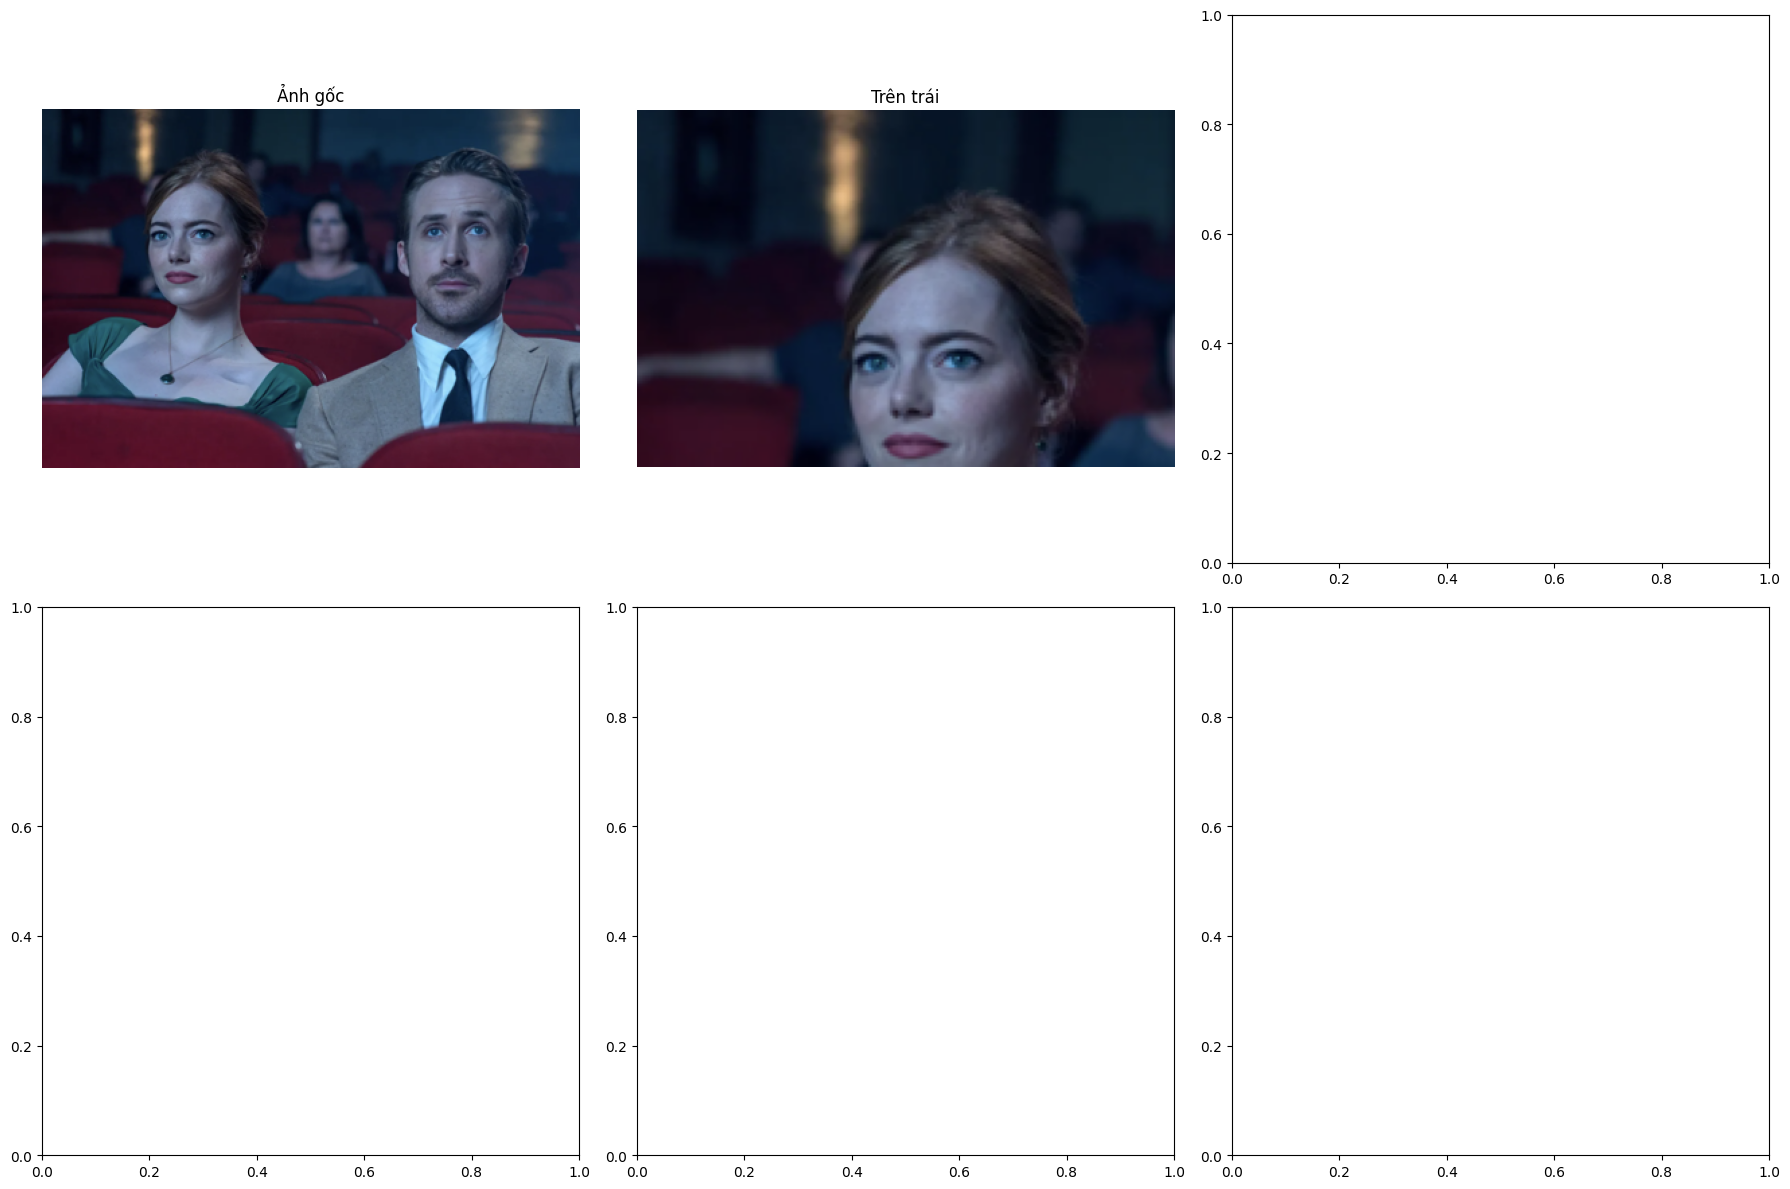

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

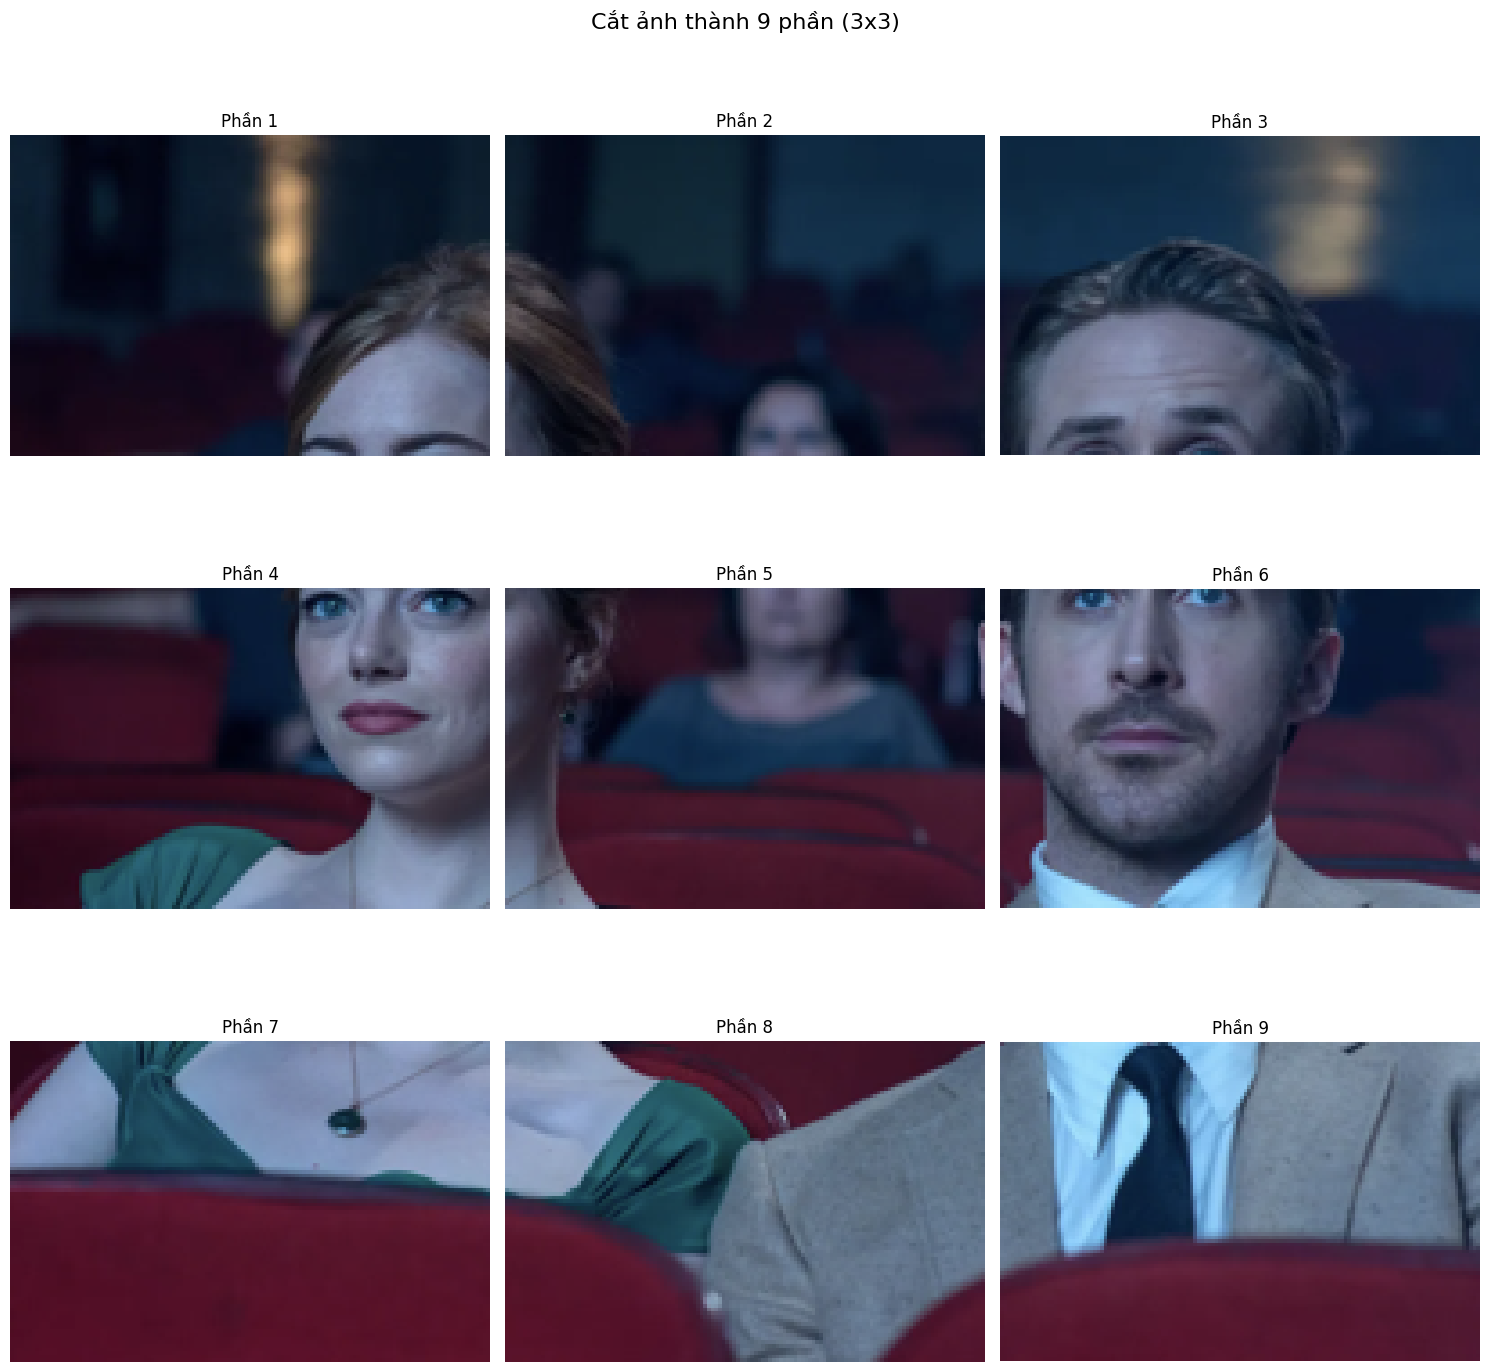

Đã cắt ảnh thành 4 phần và 9 phần


In [12]:
def cat_anh_thanh_nhieu_phan():
  print("=== CẮT ẢNH THÀNH NHIỀU PHẦN ===")
  # Cắt thành 4 phần (2x2)
  half_width = width // 2
  half_height = height // 2
  # Cắt 4 góc
  top_left = img_goc.crop((0, 0, half_width, half_height))
  top_right = img_goc.crop((half_width, 0, width, half_height))
  bottom_left = img_goc.crop((0, half_height, half_width, height))
  bottom_right = img_goc.crop((half_width, half_height, width, height))
  # Cắt thành 9 phần (3x3)
  third_width = width // 3
  third_height = height // 3
  parts_3x3 = []
  for i in range(3):
    for j in range(3):
      left = j * third_width
      top = i * third_height
      right = (j + 1) * third_width if j < 2 else width
      bottom = (i + 1) * third_height if i < 2 else height
      part = img_goc.crop((left, top, right, bottom))
      parts_3x3.append(part)
  # Hiển thị cắt 2x2
  fig, axes = plt.subplots(2, 3, figsize=(18, 12))
  # Ảnh gốc
  axes[0, 0].imshow(img_goc)
  axes[0, 0].set_title('Ảnh gốc')
  axes[0, 0].axis('off')
  # 4 phần 2x2
  parts_2x2 = [top_left, top_right, bottom_left, bottom_right]
  titles_2x2 = ['Trên trái', 'Trên phải', 'Dưới trái', 'Dưới phải']
  for i, (part, title) in enumerate(zip(parts_2x2, titles_2x2)):
    if i < 4:
      row, col = (0, i+1) if i < 2 else (1, i-1)
      axes[row, col].imshow(part)
      axes[row, col].set_title(title)
      axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()
  # Hiển thị cắt 3x3
  fig, axes = plt.subplots(3, 3, figsize=(15, 15))
  fig.suptitle('Cắt ảnh thành 9 phần (3x3)', fontsize=16)
  for i, part in enumerate(parts_3x3):
    row, col = i // 3, i % 3
    axes[row, col].imshow(part)
    axes[row, col].set_title(f'Phần {i+1}')
    axes[row, col].axis('off')
  plt.tight_layout()
  plt.show()
  print("Đã cắt ảnh thành 4 phần và 9 phần")
  return parts_2x2, parts_3x3
parts_2x2, parts_3x3 = cat_anh_thanh_nhieu_phan()

=== GHÉP ẢNH CƠ BẢN ===


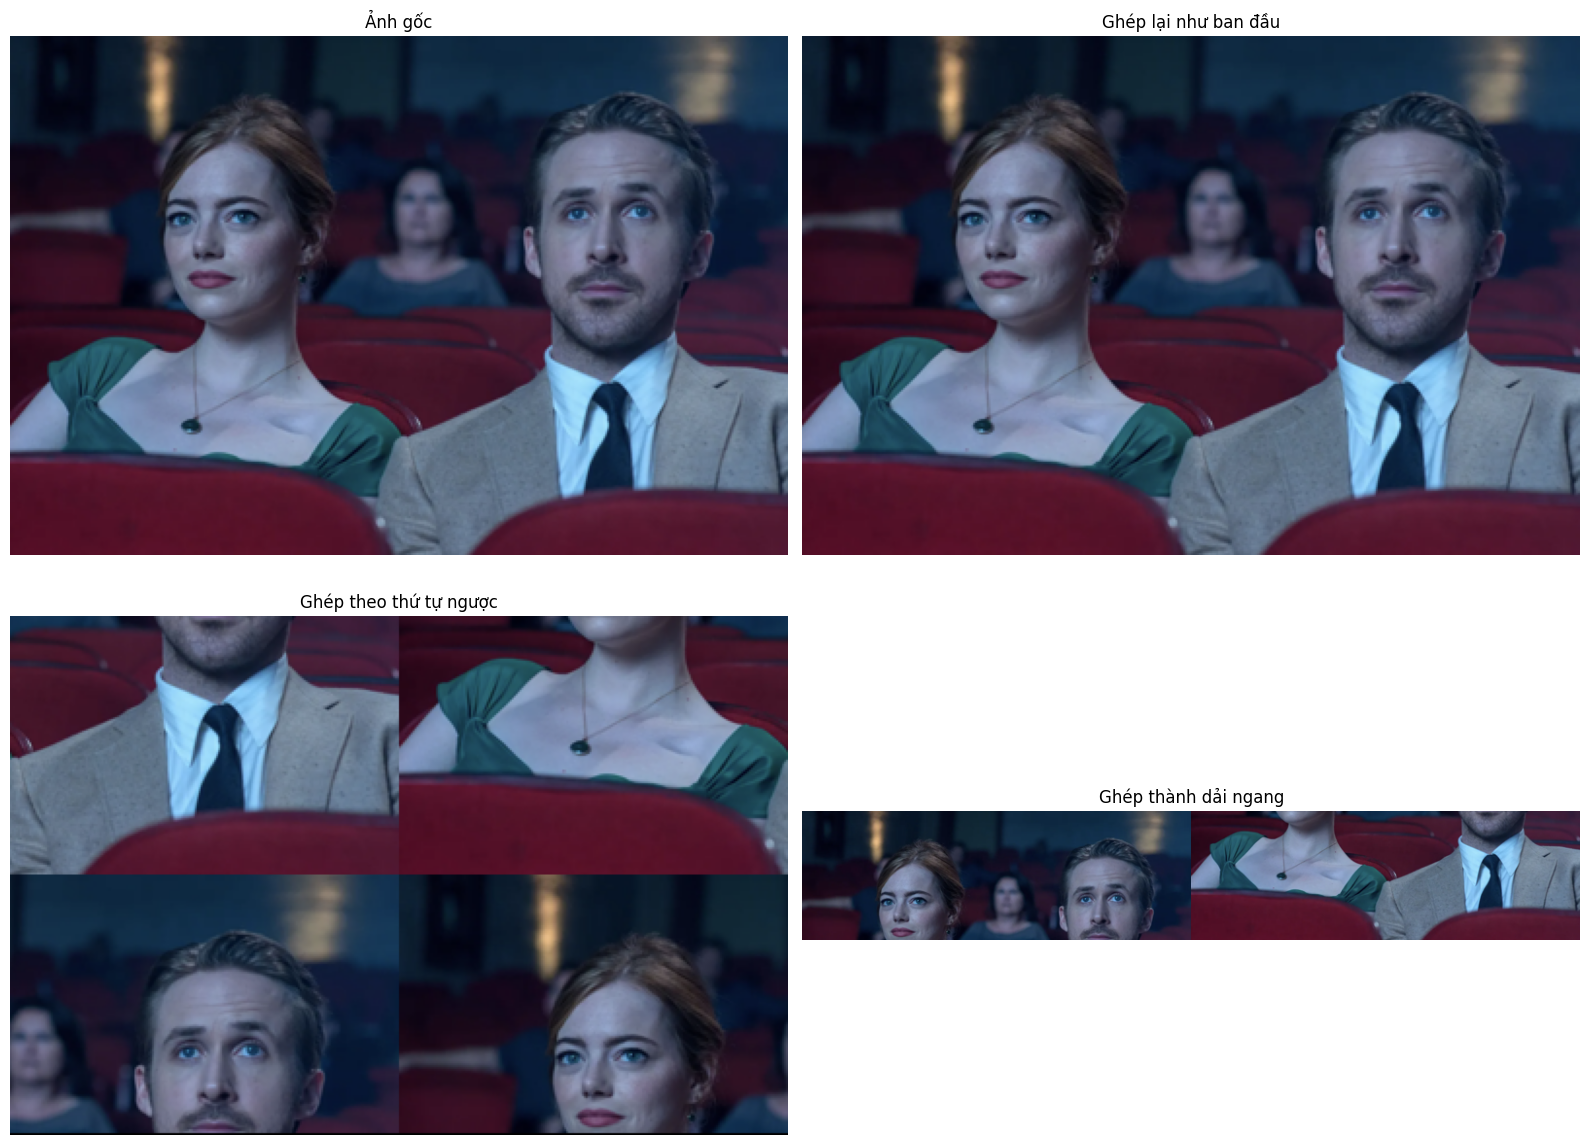

Đã ghép ảnh theo nhiều cách khác nhau


In [13]:
def ghep_anh_co_ban():
  print("=== GHÉP ẢNH CƠ BẢN ===")
  # Lấy 4 phần đã cắt
  top_left, top_right, bottom_left, bottom_right = parts_2x2
  half_width = width // 2
  half_height = height // 2
  # 1. Ghép lại như ban đầu
  combined_original = Image.new('RGB', (width, height))
  combined_original.paste(top_left, (0, 0))
  combined_original.paste(top_right, (half_width, 0))
  combined_original.paste(bottom_left, (0, half_height))
  combined_original.paste(bottom_right, (half_width, half_height))
  # 2. Ghép theo thứ tự ngược (tạo hiệu ứng xoay)
  combined_rotated = Image.new('RGB', (width, height))
  combined_rotated.paste(bottom_right, (0, 0))
  combined_rotated.paste(bottom_left, (half_width, 0))
  combined_rotated.paste(top_right, (0, half_height))
  combined_rotated.paste(top_left, (half_width, half_height))
  # 3. Ghép thành dải ngang
  combined_horizontal = Image.new('RGB', (width * 2, height // 2))
  combined_horizontal.paste(top_left, (0, 0))
  combined_horizontal.paste(top_right, (half_width, 0))
  combined_horizontal.paste(bottom_left, (width, 0))
  combined_horizontal.paste(bottom_right, (width + half_width, 0))
  # Hiển thị kết quả
  fig, axes = plt.subplots(2, 2, figsize=(16, 12))
  # Ảnh gốc
  axes[0, 0].imshow(img_goc)
  axes[0, 0].set_title('Ảnh gốc')
  axes[0, 0].axis('off')
  # Ghép lại như cũ
  axes[0, 1].imshow(combined_original)
  axes[0, 1].set_title('Ghép lại như ban đầu')
  axes[0, 1].axis('off')
  # Ghép xoay
  axes[1, 0].imshow(combined_rotated)
  axes[1, 0].set_title('Ghép theo thứ tự ngược')
  axes[1, 0].axis('off')
  # Ghép ngang
  axes[1, 1].imshow(combined_horizontal)
  axes[1, 1].set_title('Ghép thành dải ngang')
  axes[1, 1].axis('off')
  plt.tight_layout()
  plt.show()
  print("Đã ghép ảnh theo nhiều cách khác nhau")
  return combined_original, combined_rotated, combined_horizontal
combined_original, combined_rotated, combined_horizontal = ghep_anh_co_ban()

=== TẠO COLLAGE SÁNG TẠO ===


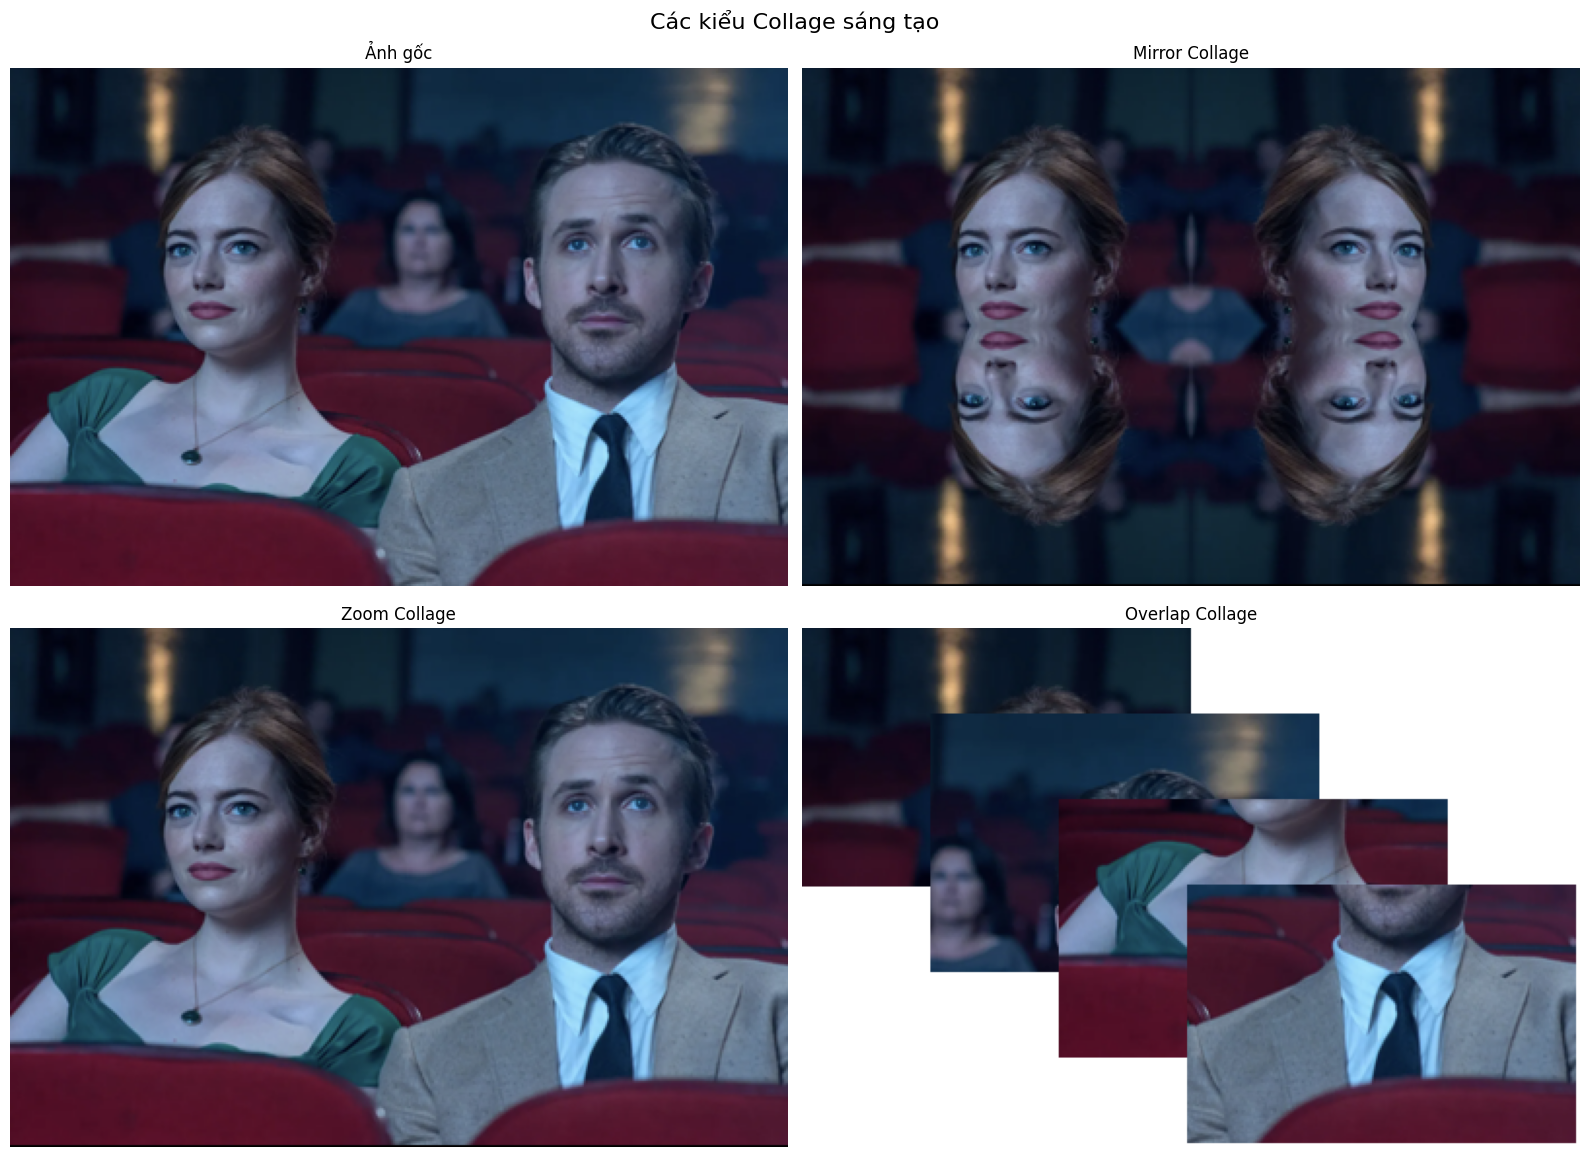

Đã tạo các collage sáng tạo


In [18]:
def tao_collage_sang_tao():
  print("=== TẠO COLLAGE SÁNG TẠO ===")
  # Lấy 4 phần ảnh
  top_left, top_right, bottom_left, bottom_right = parts_2x2
  half_width = width // 2
  half_height = height // 2
  # 1. Collage Mirror (hiệu ứng gương)
  mirror_collage = Image.new('RGB', (width, height))
  # Ghép đối xứng
  mirror_collage.paste(top_left, (0, 0))
  mirror_collage.paste(top_left.transpose(Image.FLIP_LEFT_RIGHT), (half_width, 0))
  mirror_collage.paste(top_left.transpose(Image.FLIP_TOP_BOTTOM), (0,
  half_height))
  mirror_collage.paste(top_left.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM),
  (half_width, half_height))
  # 2. Collage Zoom (phóng to từng phần)
  zoom_collage = Image.new('RGB', (width, height))
  # Resize từng phần
  zoom_parts = []
  for part in parts_2x2:
    zoomed = part.resize((half_width, half_height))
    zoom_parts.append(zoomed)
  # Ghép các phần đã resize
  zoom_collage.paste(zoom_parts[0], (0, 0))
  zoom_collage.paste(zoom_parts[1], (half_width, 0))
  zoom_collage.paste(zoom_parts[2], (0, half_height))
  zoom_collage.paste(zoom_parts[3], (half_width, half_height))
  # 3. Collage Overlap (chồng lấp)
  overlap_collage = Image.new('RGB', (width, height), color='white')
  # Ghép chồng lên nhau với độ trong suốt
  for i, part in enumerate(parts_2x2):
    x = i * (width // 6)
    y = i * (height // 6)
    # Resize nhỏ hơn để tạo hiệu ứng chồng lấp
    small_part = part.resize((width//2, height//2))
    overlap_collage.paste(small_part, (x, y))
  # Hiển thị các collage
  fig, axes = plt.subplots(2, 2, figsize=(16, 12))
  fig.suptitle('Các kiểu Collage sáng tạo', fontsize=16)
  # Ảnh gốc
  axes[0, 0].imshow(img_goc)
  axes[0, 0].set_title('Ảnh gốc')
  axes[0, 0].axis('off')
  # Mirror collage
  axes[0, 1].imshow(mirror_collage)
  axes[0, 1].set_title('Mirror Collage')
  axes[0, 1].axis('off')
  # Zoom collage
  axes[1, 0].imshow(zoom_collage)
  axes[1, 0].set_title('Zoom Collage')
  axes[1, 0].axis('off')
  # Overlap collage
  axes[1, 1].imshow(overlap_collage)
  axes[1, 1].set_title('Overlap Collage')
  axes[1, 1].axis('off')
  plt.tight_layout()
  plt.show()
  print("Đã tạo các collage sáng tạo")
  return mirror_collage, zoom_collage, overlap_collage
mirror_collage, zoom_collage, overlap_collage = tao_collage_sang_tao()

=== TẠO MOSAIC TỪ 9 PHẦN ===


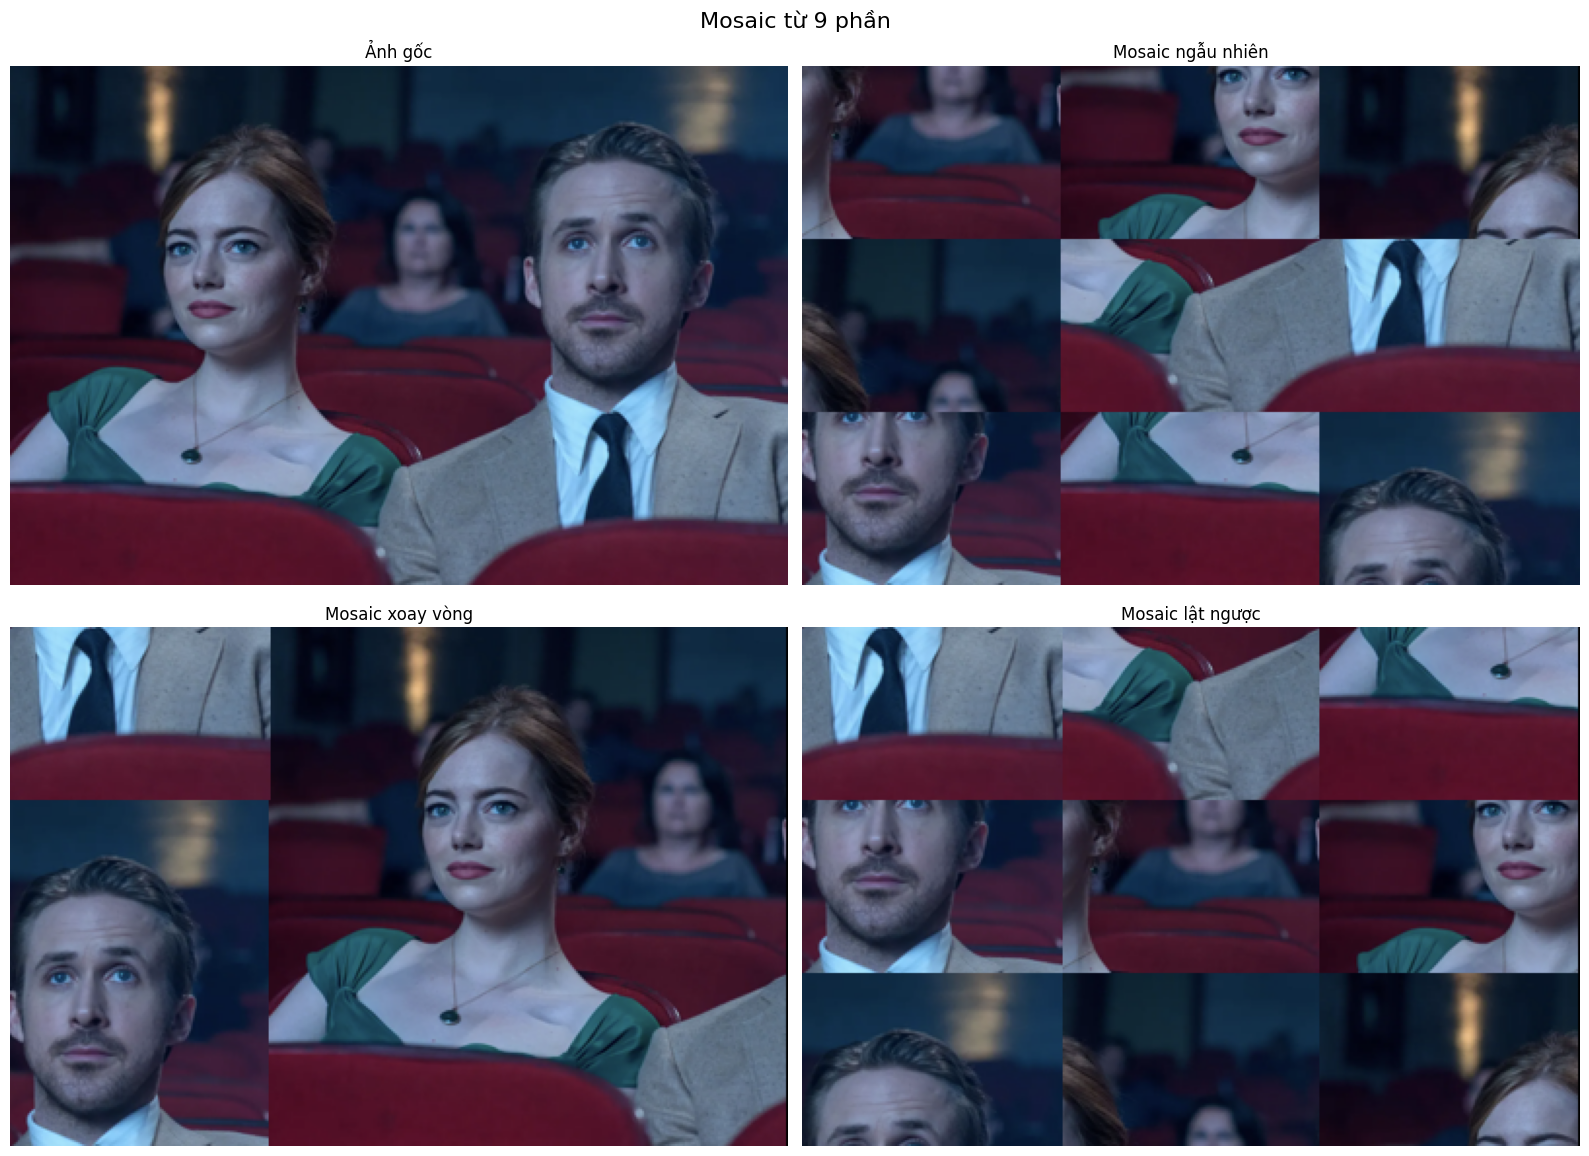

Đã tạo mosaic với các cách sắp xếp khác nhau


In [19]:
def tao_mosaic_9_phan():
  print("=== TẠO MOSAIC TỪ 9 PHẦN ===")
  # Sử dụng 9 phần đã cắt
  third_width = width // 3
  third_height = height // 3
  # 1. Mosaic xáo trộn ngẫu nhiên
  import random
  shuffled_parts = parts_3x3.copy()
  random.shuffle(shuffled_parts)
  mosaic_random = Image.new('RGB', (width, height))
  for i, part in enumerate(shuffled_parts):
    row, col = i // 3, i % 3
    x = col * third_width
    y = row * third_height
    mosaic_random.paste(part, (x, y))
  # 2. Mosaic xoay vòng
  mosaic_rotate = Image.new('RGB', (width, height))
  # Xoay vòng: 0→8, 1→0, 2→1, ..., 8→7
  for i in range(9):
    new_pos = (i + 1) % 9
    row, col = new_pos // 3, new_pos % 3
    x = col * third_width
    y = row * third_height
    mosaic_rotate.paste(parts_3x3[i], (x, y))
  # 3. Mosaic lật ngược
  mosaic_flip = Image.new('RGB', (width, height))
  for i, part in enumerate(parts_3x3):
  # Đảo ngược vị trí: 0→8, 1→7, 2→6, ...
    new_pos = 8 - i
    row, col = new_pos // 3, new_pos % 3
    x = col * third_width
    y = row * third_height
    mosaic_flip.paste(part, (x, y))
  # Hiển thị kết quả
  fig, axes = plt.subplots(2, 2, figsize=(16, 12))
  fig.suptitle('Mosaic từ 9 phần', fontsize=16)
  # Ảnh gốc
  axes[0, 0].imshow(img_goc)
  axes[0, 0].set_title('Ảnh gốc')
  axes[0, 0].axis('off')
  # Mosaic ngẫu nhiên
  axes[0, 1].imshow(mosaic_random)
  axes[0, 1].set_title('Mosaic ngẫu nhiên')
  axes[0, 1].axis('off')
  # Mosaic xoay vòng
  axes[1, 0].imshow(mosaic_rotate)
  axes[1, 0].set_title('Mosaic xoay vòng')
  axes[1, 0].axis('off')
  # Mosaic lật ngược
  axes[1, 1].imshow(mosaic_flip)
  axes[1, 1].set_title('Mosaic lật ngược')
  axes[1, 1].axis('off')
  plt.tight_layout()
  plt.show()
  print("Đã tạo mosaic với các cách sắp xếp khác nhau")
  return mosaic_random, mosaic_rotate, mosaic_flip
mosaic_random, mosaic_rotate, mosaic_flip = tao_mosaic_9_phan()

In [21]:
def luu_ket_qua():
  # Tạo thư mục kết quả
  thu_muc_ket_qua = "/content/drive/MyDrive/Lab_CropPaste_Results/"
  if not os.path.exists(thu_muc_ket_qua):
    os.makedirs(thu_muc_ket_qua) # Corrected indentation

  # Tạo lại các kết quả chính để lưu
  # Cắt vùng giữa
  left = width // 4
  top = height // 4
  right = 3 * width // 4
  bottom = 3 * height // 4
  cropped_center = img_goc.crop((left, top, right, bottom))

  # Ghép lại như ban đầu
  half_width = width // 2
  half_height = height // 2
  combined = Image.new('RGB', (width, height))
  combined.paste(parts_2x2[0], (0, 0))
  combined.paste(parts_2x2[1], (half_width, 0))
  combined.paste(parts_2x2[2], (0, half_height))
  combined.paste(parts_2x2[3], (half_width, half_height))

  # Lưu các file
  ten_anh_goc = os.path.splitext(danh_sach_anh[0])[0]
  ket_qua_luu = {
    'cropped_center': cropped_center,
    'combined_original': combined,
    'combined_rotated': combined_rotated,
    'mirror_collage': mirror_collage,
    'zoom_collage': zoom_collage,
    'overlap_collage': overlap_collage,
    'mosaic_random': mosaic_random,
    'mosaic_rotate': mosaic_rotate,
    'mosaic_flip': mosaic_flip
  }

  for ten, anh in ket_qua_luu.items():
    filename = f"{ten_anh_goc}_{ten}.jpg"
    filepath = os.path.join(thu_muc_ket_qua, filename)
    # Convert RGBA to RGB if necessary before saving as JPG
    if anh.mode == 'RGBA':
      anh = anh.convert('RGB')
    anh.save(filepath, quality=95)
    print(f"✓ Đã lưu: {filename}")

  # Lưu cả 4 phần riêng lẻ
  phan_names = ['top_left', 'top_right', 'bottom_left', 'bottom_right']
  for i, part in enumerate(parts_2x2):
    filename = f"{ten_anh_goc}_{phan_names[i]}.jpg"
    filepath = os.path.join(thu_muc_ket_qua, filename)
    # Convert RGBA to RGB if necessary before saving as JPG
    if part.mode == 'RGBA':
      part = part.convert('RGB')
    part.save(filepath, quality=95)
    print(f"✓ Đã lưu: {filename}")

  print("\nĐã lưu tất cả các kết quả vào thư mục!") # Corrected print statement

luu_ket_qua() # Corrected indentation

✓ Đã lưu: bai3_flip_horizontal_cropped_center.jpg
✓ Đã lưu: bai3_flip_horizontal_combined_original.jpg
✓ Đã lưu: bai3_flip_horizontal_combined_rotated.jpg
✓ Đã lưu: bai3_flip_horizontal_mirror_collage.jpg
✓ Đã lưu: bai3_flip_horizontal_zoom_collage.jpg
✓ Đã lưu: bai3_flip_horizontal_overlap_collage.jpg
✓ Đã lưu: bai3_flip_horizontal_mosaic_random.jpg
✓ Đã lưu: bai3_flip_horizontal_mosaic_rotate.jpg
✓ Đã lưu: bai3_flip_horizontal_mosaic_flip.jpg
✓ Đã lưu: bai3_flip_horizontal_top_left.jpg
✓ Đã lưu: bai3_flip_horizontal_top_right.jpg
✓ Đã lưu: bai3_flip_horizontal_bottom_left.jpg
✓ Đã lưu: bai3_flip_horizontal_bottom_right.jpg

Đã lưu tất cả các kết quả vào thư mục!


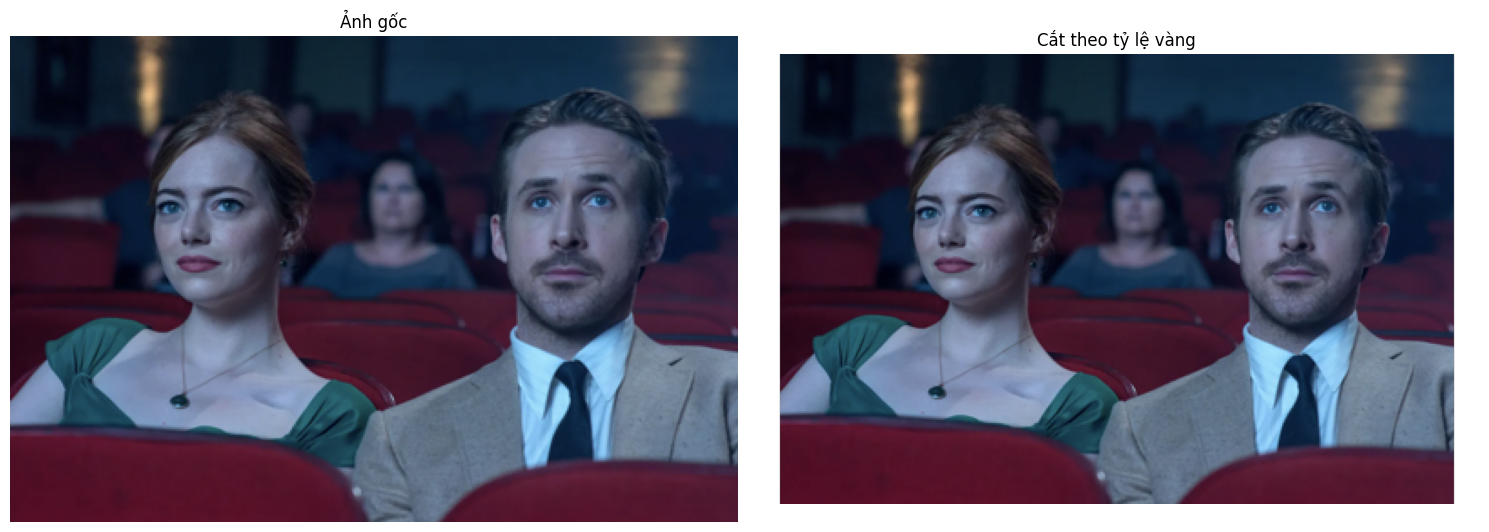

In [24]:
def cat_theo_ty_le_vang():
  # Tỷ lệ vàng ≈ 1.618
  golden_ratio = 1.618
  # Tính kích thước theo tỷ lệ vàng
  if width > height:
    new_width = int(height * golden_ratio)
    new_height = height
    left = (width - new_width) // 2
    top = 0
    right = left + new_width
    bottom = height
  else:
    new_width = width
    new_height = int(width * golden_ratio)
    left = 0
    top = (height - new_height) // 2
    right = width
    bottom = top + new_height
  golden_crop = img_goc.crop((left, top, right, bottom)) # Moved outside if/else to ensure it's always assigned
  # Hiển thị kết quả
  fig, axes = plt.subplots(1, 2, figsize=(15, 6))
  axes[0].imshow(img_goc)
  axes[0].set_title('Ảnh gốc')
  axes[0].axis('off')
  axes[1].imshow(golden_crop)
  axes[1].set_title('Cắt theo tỷ lệ vàng')
  axes[1].axis('off')
  plt.tight_layout()
  plt.show()
  return golden_crop
# Chạy bài tập
golden_crop = cat_theo_ty_le_vang()

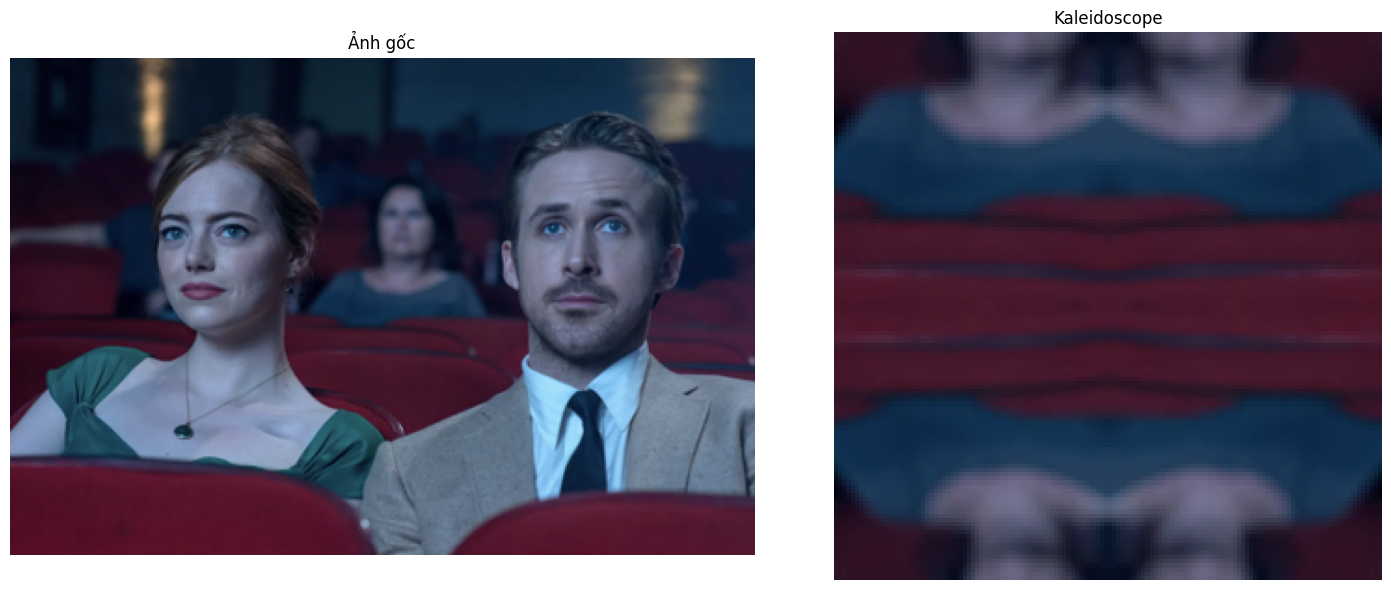

In [27]:
def tao_kaleidoscope():
  # Cắt một phần nhỏ ở giữa
  center_size = min(width, height) // 4
  left = (width - center_size) // 2
  top = (height - center_size) // 2
  center_part = img_goc.crop((left, top, left + center_size, top + center_size))
  # Tạo kaleidoscope bằng cách lật và xoay
  kaleidoscope = Image.new('RGB', (center_size * 2, center_size * 2))
  # 4 góc với các phép biến đổi khác nhau
  kaleidoscope.paste(center_part, (0, 0))
  kaleidoscope.paste(center_part.transpose(Image.FLIP_LEFT_RIGHT), (center_size,
  0))
  kaleidoscope.paste(center_part.transpose(Image.FLIP_TOP_BOTTOM), (0,
  center_size))
  kaleidoscope.paste(center_part.rotate(180), (center_size, center_size))
  # Hiển thị kết quả
  fig, axes = plt.subplots(1, 2, figsize=(15, 6))
  axes[0].imshow(img_goc)
  axes[0].set_title('Ảnh gốc')
  axes[0].axis('off')
  axes[1].imshow(kaleidoscope)
  axes[1].set_title('Kaleidoscope')
  axes[1].axis('off')
  plt.tight_layout()
  plt.show()
  return kaleidoscope
kaleidoscope_result = tao_kaleidoscope()